# XGBoost Regressor - Used Car Price Prediction

## 1. Project Overview

This project implements an **XGBoost Regressor** to predict used-car prices from the provided dataset. The workflow begins with the complete raw dataset, inspects its structure, handles missing values and duplicates, removes unsuitable identifier-like fields where appropriate, preprocesses numerical and categorical features, trains an XGBoost regression model, evaluates it using standard regression metrics, and analyzes feature importance.

**Detected target column:** `sale_price`

XGBoost builds an ensemble of decision trees sequentially, with each new tree focusing on correcting errors made by the previous trees. This makes it effective for structured tabular regression problems containing nonlinear relationships and feature interactions.


## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

In [2]:
df = pd.read_csv("Used_Car_Price_Prediction.csv")
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (7400, 29)


,car_name,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,variant,...,total_owners,broker_quote,original_price,car_rating,ad_created_on,fitness_certificate,emi_starts_from,booking_down_pymnt,reserved,warranty_avail
0,maruti swift,2015,petrol,8063,386399,noida,18715,hatchback,manual,lxi opt,...,2,397677,404177.0,great,2021-04-04T07:09:18.583,True,8975,57960,False,False
1,maruti alto 800,2016,petrol,23104,265499,noida,2676,hatchback,manual,lxi,...,1,272935,354313.0,great,2021-03-22T14:07:32.833,True,6167,39825,False,False
2,hyundai grand i10,2017,petrol,23402,477699,noida,609,hatchback,manual,sports 1.2 vtvt,...,1,469605,NaN,great,2021-03-20T05:36:31.311,True,11096,71655,False,False
3,maruti swift,2013,diesel,39124,307999,noida,6511,hatchback,manual,vdi,...,1,294262,374326.0,great,2021-01-21T12:59:19.299,True,7154,46200,False,False
4,hyundai grand i10,2015,petrol,22116,361499,noida,3225,hatchback,manual,magna 1.2 vtvt,...,1,360716,367216.0,great,2021-04-01T13:33:40.733,True,8397,54225,False,False


## 3. Explore Dataset

In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

display(df.describe(include='all').T)

Columns:
['car_name', 'yr_mfr', 'fuel_type', 'kms_run', 'sale_price', 'city', 'times_viewed', 'body_type', 'transmission', 'variant', 'assured_buy', 'registered_city', 'registered_state', 'is_hot', 'rto', 'source', 'make', 'model', 'car_availability', 'total_owners', 'broker_quote', 'original_price', 'car_rating', 'ad_created_on', 'fitness_certificate', 'emi_starts_from', 'booking_down_pymnt', 'reserved', 'warranty_avail']

Data types:
car_name                object
yr_mfr                   int64
fuel_type               object
kms_run                  int64
sale_price               int64
city                    object
times_viewed             int64
body_type               object
transmission            object
variant                 object
assured_buy               bool
registered_city         object
registered_state        object
is_hot                    bool
rto                     object
source                  object
make                    object
model                   object
ca

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
car_name,7400,185,maruti swift,535,NaN,NaN,NaN,NaN,NaN,NaN,NaN
yr_mfr,7400.0,NaN,NaN,NaN,2013.885676,3.087613,1996.0,2012.0,2014.0,2016.0,2021.0
fuel_type,7400,5,petrol,4659,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kms_run,7400.0,NaN,NaN,NaN,62624.52,43532.042371,60.0,31885.25,55765.0,84184.0,996609.0
sale_price,7400.0,NaN,NaN,NaN,454889.192027,282702.329741,0.0,281174.0,382449.0,540149.0,3866000.0
city,7400,13,mumbai,1336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
times_viewed,7400.0,NaN,NaN,NaN,1550.706081,2080.952842,3.0,554.75,1088.0,1926.5,61930.0
body_type,7297,5,hatchback,4358,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,6844,2,manual,6215,NaN,NaN,NaN,NaN,NaN,NaN,NaN
variant,7400,943,vxi,674,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Missing Values and Duplicates

In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
print("Missing values:")
display(missing[missing > 0].to_frame("missing_values"))

print("Duplicate rows:", df.duplicated().sum())

Missing values:


,missing_values
original_price,3280
car_availability,620
transmission,556
source,126
body_type,103
registered_state,10
registered_city,10
car_rating,9
fitness_certificate,8
ad_created_on,1


Duplicate rows: 1


## 5. Data Cleaning

In [5]:
# Remove exact duplicate rows
df = df.drop_duplicates().copy()

target = 'sale_price'

# Ensure the target is numeric. Non-numeric target values become NaN and are removed.
df[target] = pd.to_numeric(df[target].astype(str).str.replace(',', '', regex=False), errors='coerce')
df = df.dropna(subset=[target])

# Automatically identify obvious identifier-like columns.
# These columns usually do not provide generalizable predictive information.
id_like = []
for col in df.columns:
    if col == target:
        continue
    name = col.lower().strip()
    unique_ratio = df[col].nunique(dropna=False) / len(df)
    if name in ['id', 'index', 'url', 'link'] or name.endswith('_id') or unique_ratio > 0.98:
        id_like.append(col)

print("Columns removed as identifier/high-cardinality row identifiers:", id_like)
df = df.drop(columns=id_like)

print("Cleaned dataset shape:", df.shape)
display(df.head())

Columns removed as identifier/high-cardinality row identifiers: ['ad_created_on']
Cleaned dataset shape: (7399, 28)


,car_name,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,variant,...,car_availability,total_owners,broker_quote,original_price,car_rating,fitness_certificate,emi_starts_from,booking_down_pymnt,reserved,warranty_avail
0,maruti swift,2015,petrol,8063,386399,noida,18715,hatchback,manual,lxi opt,...,in_stock,2,397677,404177.0,great,True,8975,57960,False,False
1,maruti alto 800,2016,petrol,23104,265499,noida,2676,hatchback,manual,lxi,...,in_stock,1,272935,354313.0,great,True,6167,39825,False,False
2,hyundai grand i10,2017,petrol,23402,477699,noida,609,hatchback,manual,sports 1.2 vtvt,...,in_stock,1,469605,NaN,great,True,11096,71655,False,False
3,maruti swift,2013,diesel,39124,307999,noida,6511,hatchback,manual,vdi,...,in_stock,1,294262,374326.0,great,True,7154,46200,False,False
4,hyundai grand i10,2015,petrol,22116,361499,noida,3225,hatchback,manual,magna 1.2 vtvt,...,in_stock,1,360716,367216.0,great,True,8397,54225,False,False


## 6. Exploratory Data Analysis

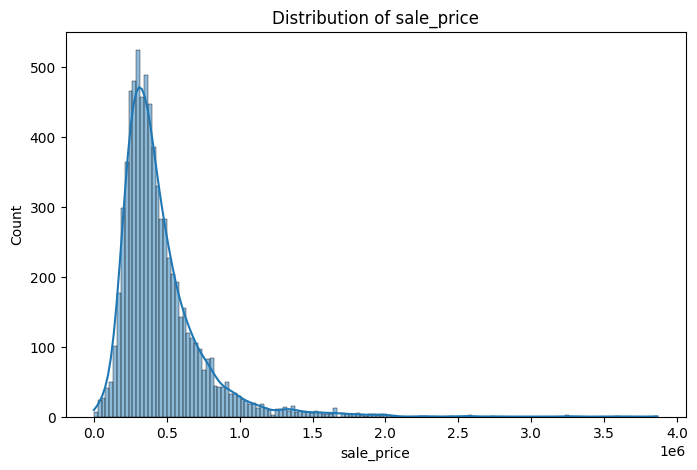

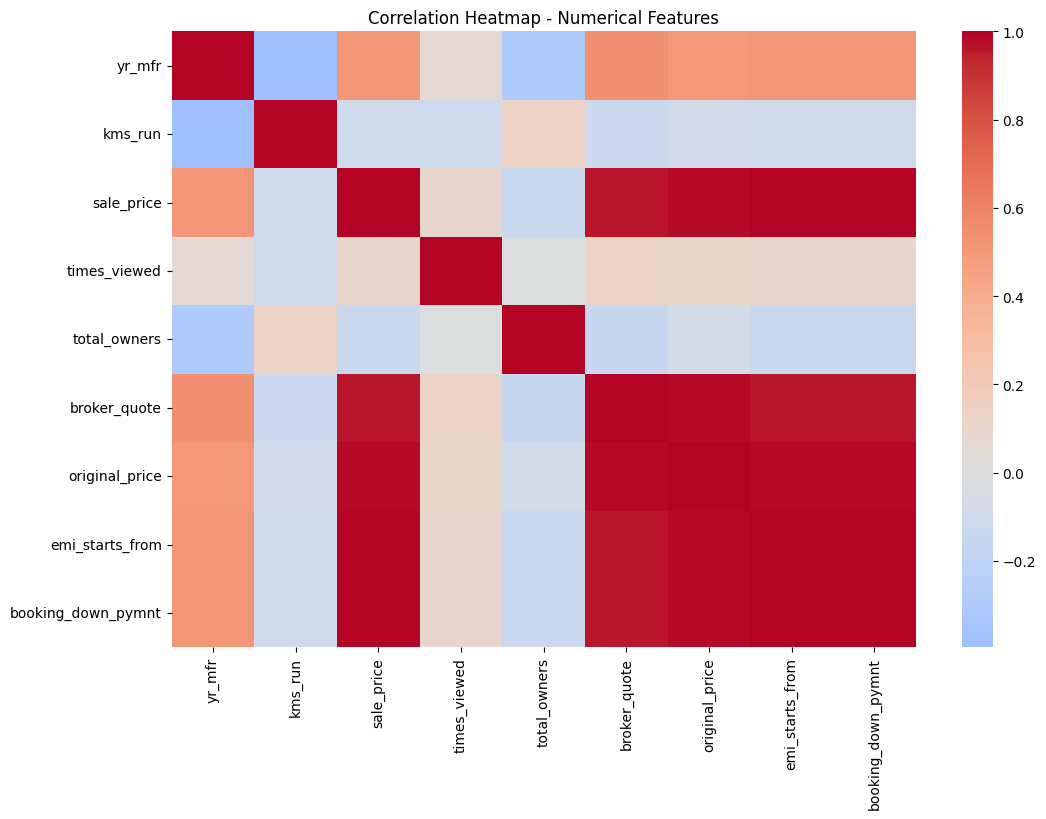

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df[target], kde=True)
plt.title(f"Distribution of {target}")
plt.xlabel(target)
plt.show()

numeric_df = df.select_dtypes(include=np.number)
if numeric_df.shape[1] > 1:
    plt.figure(figsize=(12, 8))
    sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0)
    plt.title("Correlation Heatmap - Numerical Features")
    plt.show()

## 7. Prepare Features and Target

In [7]:
X = df.drop(columns=[target])
y = df[target]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical features:", numeric_features)
print("\nCategorical features:", categorical_features)
print("\nNumber of features before encoding:", X.shape[1])

Numerical features: ['yr_mfr', 'kms_run', 'times_viewed', 'total_owners', 'broker_quote', 'original_price', 'emi_starts_from', 'booking_down_pymnt']

Categorical features: ['car_name', 'fuel_type', 'city', 'body_type', 'transmission', 'variant', 'assured_buy', 'registered_city', 'registered_state', 'is_hot', 'rto', 'source', 'make', 'model', 'car_availability', 'car_rating', 'fitness_certificate', 'reserved', 'warranty_avail']

Number of features before encoding: 27


## 8. Preprocessing Pipeline

In [8]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

## 9. Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 5919
Testing samples : 1480


## 10. Train XGBoost Regressor

In [10]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb_model)
])

model.fit(X_train, y_train)
print("XGBoost Regressor training complete.")

XGBoost Regressor training complete.


## 11. Make Predictions

In [11]:
y_pred = model.predict(X_test)
print("Predictions generated:", len(y_pred))

Predictions generated: 1480


## 12. Model Evaluation

Regression models predict continuous numerical values, so classification accuracy is not applicable. The model is evaluated using:

- **MAE (Mean Absolute Error):** Average absolute difference between actual and predicted prices.
- **MSE (Mean Squared Error):** Average squared prediction error, giving greater weight to large errors.
- **RMSE (Root Mean Squared Error):** Square root of MSE, expressed in the same units as the target.
- **R² Score:** Proportion of variance in used-car prices explained by the model. Higher values indicate stronger predictive performance.

In [12]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=" * 52)
print("XGBoost Regressor Evaluation Metrics")
print("=" * 52)
print(f"Mean Absolute Error (MAE) : {mae:,.2f}")
print(f"Mean Squared Error (MSE)  : {mse:,.2f}")
print(f"Root Mean Squared Error   : {rmse:,.2f}")
print(f"R² Score                  : {r2:.4f}")
print("=" * 52)

XGBoost Regressor Evaluation Metrics
Mean Absolute Error (MAE) : 3,563.71
Mean Squared Error (MSE)  : 1,178,367,872.00
Root Mean Squared Error   : 34,327.36
R² Score                  : 0.9869


## 13. Actual vs Predicted Prices

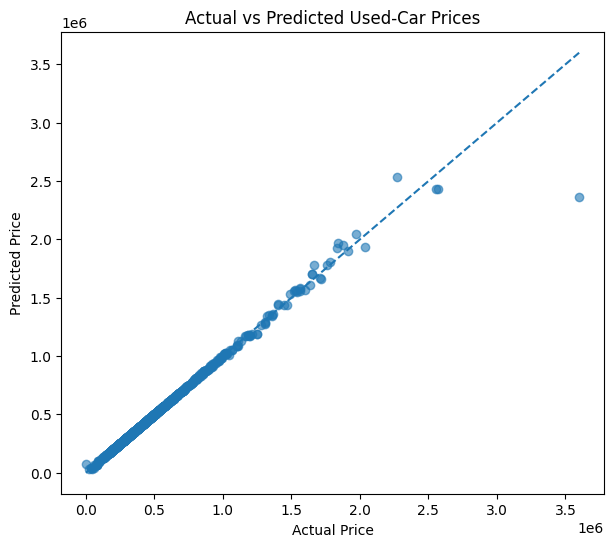

In [13]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())
plt.plot([minimum, maximum], [minimum, maximum], linestyle='--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Used-Car Prices")
plt.show()

## 14. Residual Analysis

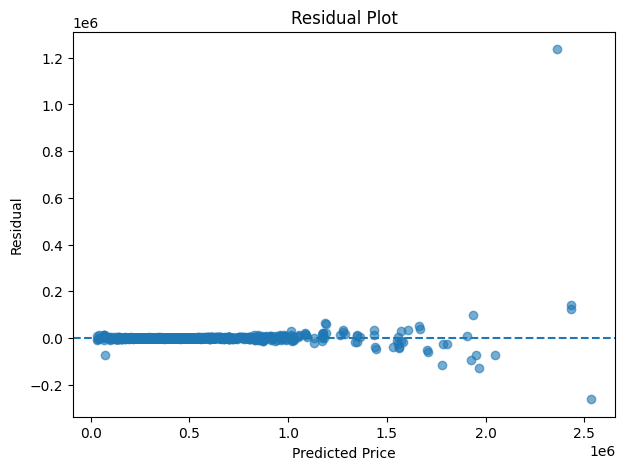

In [14]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

## 15. Feature Importance

,Feature,Importance
6,num__emi_starts_from,0.334713
7,num__booking_down_pymnt,0.271057
1539,cat__source_inperson_sale,0.065525
1296,cat__is_hot_False,0.049527
1297,cat__is_hot_True,0.037314
1750,cat__car_rating_good,0.023435
195,cat__city_gurgaon,0.021858
445,cat__variant_3.0 v 6 premium luxury,0.016667
4,num__broker_quote,0.015406
71,cat__car_name_jaguar xj l,0.014353


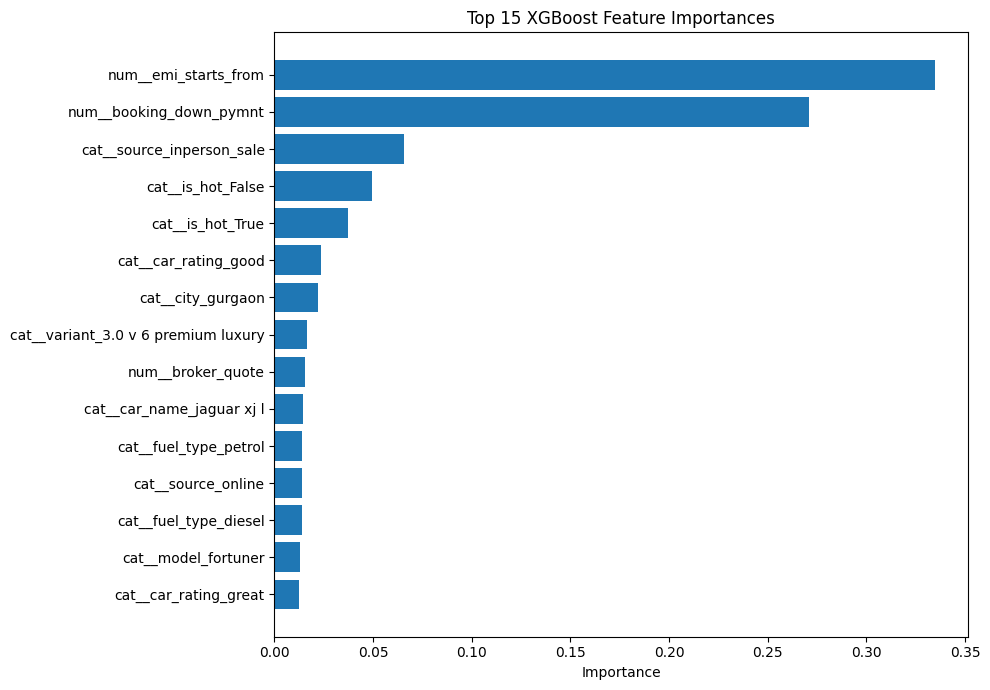

In [15]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
importances = model.named_steps['regressor'].feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

display(feature_importance.head(20))

plt.figure(figsize=(10, 7))
top_features = feature_importance.head(15).sort_values('Importance')
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel("Importance")
plt.title("Top 15 XGBoost Feature Importances")
plt.tight_layout()
plt.show()

## 16. Potential Target Leakage Analysis

The initial XGBoost model achieved an exceptionally high R² score. Feature importance analysis showed that `emi_starts_from` and `booking_down_pymnt` were the two dominant predictors, while `broker_quote` also contains potentially price-related information.

Because these financing and quotation variables may be directly derived from or strongly influenced by the vehicle's sale price, they can introduce **potential target leakage**. To obtain a more realistic estimate of predictive performance, a second XGBoost model is trained after removing these potentially price-derived features.

The original full-feature model is retained for comparison.

In [16]:
# Create a leakage-controlled feature set
potential_leakage_features = [
    'emi_starts_from',
    'booking_down_pymnt',
    'broker_quote'
]

leakage_features_present = [
    col for col in potential_leakage_features if col in X.columns
]

X_clean = X.drop(columns=leakage_features_present)

print("Potential leakage features removed:", leakage_features_present)
print("Original feature count:", X.shape[1])
print("Leakage-controlled feature count:", X_clean.shape[1])

# Identify feature types again
numeric_features_clean = X_clean.select_dtypes(include=np.number).columns.tolist()
categorical_features_clean = X_clean.select_dtypes(exclude=np.number).columns.tolist()

# Rebuild preprocessing pipeline
numeric_transformer_clean = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer_clean = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_clean = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_clean, numeric_features_clean),
        ('cat', categorical_transformer_clean, categorical_features_clean)
    ]
)

# Use the same split settings for a fair comparison
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y, test_size=0.20, random_state=42
)

xgb_model_clean = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

model_clean = Pipeline(steps=[
    ('preprocessor', preprocessor_clean),
    ('regressor', xgb_model_clean)
])

model_clean.fit(X_train_clean, y_train_clean)
y_pred_clean = model_clean.predict(X_test_clean)

# Evaluate leakage-controlled model
mae_clean = mean_absolute_error(y_test_clean, y_pred_clean)
mse_clean = mean_squared_error(y_test_clean, y_pred_clean)
rmse_clean = np.sqrt(mse_clean)
r2_clean = r2_score(y_test_clean, y_pred_clean)

print("=" * 60)
print("Leakage-Controlled XGBoost Regressor Evaluation")
print("=" * 60)
print(f"Mean Absolute Error (MAE) : {mae_clean:,.2f}")
print(f"Mean Squared Error (MSE)  : {mse_clean:,.2f}")
print(f"Root Mean Squared Error   : {rmse_clean:,.2f}")
print(f"R² Score                  : {r2_clean:.4f}")
print("=" * 60)

comparison = pd.DataFrame({
    "Model": ["Full-Feature XGBoost", "Leakage-Controlled XGBoost"],
    "MAE": [mae, mae_clean],
    "RMSE": [rmse, rmse_clean],
    "R² Score": [r2, r2_clean]
})

display(comparison.round({"MAE": 2, "RMSE": 2, "R² Score": 4}))

Potential leakage features removed: ['emi_starts_from', 'booking_down_pymnt', 'broker_quote']
Original feature count: 27
Leakage-controlled feature count: 24
Leakage-Controlled XGBoost Regressor Evaluation
Mean Absolute Error (MAE) : 35,335.88
Mean Squared Error (MSE)  : 6,391,141,376.00
Root Mean Squared Error   : 79,944.61
R² Score                  : 0.9291


,Model,MAE,RMSE,R² Score
0,Full-Feature XGBoost,3563.71,34327.36,0.9869
1,Leakage-Controlled XGBoost,35335.88,79944.61,0.9291


## 17. Key Findings

- The XGBoost Regressor demonstrated strong performance for predicting used-car sale prices from structured tabular data containing both numerical and categorical features.
- Missing numerical values were handled using median imputation, while missing categorical values were handled using most-frequent-value imputation through the preprocessing pipeline.
- Categorical features were transformed using One-Hot Encoding to make them suitable for model training.
- The initial full-feature XGBoost model achieved an exceptionally high **R² score of 0.9869**, with an **MAE of 3,563.71** and an **RMSE of 34,327.36**.
- Feature importance analysis revealed that `emi_starts_from` and `booking_down_pymnt` were the two most influential predictors, raising concerns about potential target leakage because these financing-related variables may be derived from or strongly influenced by the vehicle's sale price.
- The `broker_quote` feature was also treated as potentially price-related and removed during the leakage-control experiment.
- After removing `emi_starts_from`, `booking_down_pymnt`, and `broker_quote`, the leakage-controlled model achieved an **R² score of 0.9291**, with an **MAE of 35,335.88** and an **RMSE of 79,944.61**.
- Although performance decreased after removing the potentially price-derived features, the leakage-controlled model still explained approximately **92.9% of the variance** in used-car sale prices.
- The leakage-controlled result provides a more realistic estimate of the model's predictive performance and demonstrates the importance of investigating unusually high model scores for potential data leakage.

## 18. Conclusion

This project demonstrated an end-to-end implementation of the **XGBoost Regressor** for predicting used-car sale prices. The workflow included data exploration, missing-value handling, categorical feature encoding, preprocessing pipelines, model training, regression evaluation, residual analysis, and feature importance analysis.

The initial full-feature XGBoost model achieved an exceptional **R² score of 0.9869**. However, feature importance analysis showed that financing-related variables such as `emi_starts_from` and `booking_down_pymnt` had a substantial influence on predictions. Since these variables, along with `broker_quote`, could contain information directly or indirectly related to the target sale price, a second leakage-controlled model was developed.

After removing the potentially price-derived features, the leakage-controlled XGBoost model achieved an **R² score of 0.9291**, explaining approximately **92.9% of the variance** in used-car sale prices. Although the prediction errors increased, this result provides a more credible assessment of the model's ability to generalize using independent vehicle characteristics.

Overall, the project demonstrates both the effectiveness of XGBoost for complex tabular regression problems and the importance of critically evaluating model performance. Feature importance and target leakage analysis showed that achieving a higher evaluation score does not necessarily mean that a model is more reliable for real-world prediction.